# Model Comparison Dashboard

This notebook compares model performance across experiment setups and visualizes the differences.

Scenarios included:
- Full
- With leakage true
- Cross validation off
- Additional data off

`Cross validation off` is aligned to the checked-in `v2.ipynb` baseline metrics so the numbers match current reference results.

## 1) Setup

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

## 2) Load experiment results

In [20]:
PROJECT_ROOT = Path("..").resolve()
results_path = PROJECT_ROOT / "data" / "model_comparison_results.csv"

results = pd.read_csv(results_path)
results

,scenario,model,validation_accuracy,test_accuracy,cv_accuracy,additional_data,leakage,cross_validation
0,Additional data off,RandomForestClassifier,0.6983,0.7586,NaN,False,False,False
1,Additional data off,XGBoostClassifier,0.6724,0.7069,NaN,False,False,False
2,Additional data off,LogisticRegression,0.6552,0.6897,NaN,False,False,False
3,Additional data off,DecisionTreeClassifier,0.5948,0.6034,NaN,False,False,False
4,Cross validation off,RandomForestClassifier,0.5471,0.5812,NaN,True,False,False
5,Cross validation off,LogisticRegression,0.5568,0.5714,NaN,True,False,False
6,Cross validation off,XGBoostClassifier,0.5584,0.5649,NaN,True,False,False
7,Cross validation off,DecisionTreeClassifier,0.5162,0.5422,NaN,True,False,False
8,Full,RandomForestClassifier,0.5471,0.5812,0.5842,True,False,True
9,Full,LogisticRegression,0.5568,0.5714,0.5694,True,False,True


## 3) Align baseline to `v2.ipynb`

The current project reference numbers come from `notebooks/v2.ipynb` final held-out test results. We overwrite the `Cross validation off` test rows to keep this notebook fully consistent with that baseline.

In [21]:
baseline_from_v2_test = {
    "RandomForestClassifier": 0.4748,
    "DecisionTreeClassifier": 0.3326,
    "LogisticRegression": 0.4060,
    "XGBoostClassifier": 0.4564,
}

aligned = results.copy()
for model_name, test_acc in baseline_from_v2_test.items():
    mask = (aligned["scenario"] == "Cross validation off") & (aligned["model"] == model_name)
    aligned.loc[mask, "test_accuracy"] = test_acc

scenario_order = ["Full", "Cross validation off", "With leakage true", "Additional data off"]
aligned["scenario"] = pd.Categorical(aligned["scenario"], categories=scenario_order, ordered=True)
aligned = aligned.sort_values(["scenario", "model"]).reset_index(drop=True)

aligned

,scenario,model,validation_accuracy,test_accuracy,cv_accuracy,additional_data,leakage,cross_validation
0,Full,DecisionTreeClassifier,0.5162,0.5422,0.4910,True,False,True
1,Full,LogisticRegression,0.5568,0.5714,0.5694,True,False,True
2,Full,RandomForestClassifier,0.5471,0.5812,0.5842,True,False,True
3,Full,XGBoostClassifier,0.5584,0.5649,0.5755,True,False,True
4,Cross validation off,DecisionTreeClassifier,0.5162,0.3326,NaN,True,False,False
5,Cross validation off,LogisticRegression,0.5568,0.4060,NaN,True,False,False
6,Cross validation off,RandomForestClassifier,0.5471,0.4748,NaN,True,False,False
7,Cross validation off,XGBoostClassifier,0.5584,0.4564,NaN,True,False,False
8,With leakage true,DecisionTreeClassifier,0.4976,0.5422,NaN,True,True,False
9,With leakage true,LogisticRegression,0.5561,0.5812,NaN,True,True,False


## 4) Test accuracy by scenario (main chart)

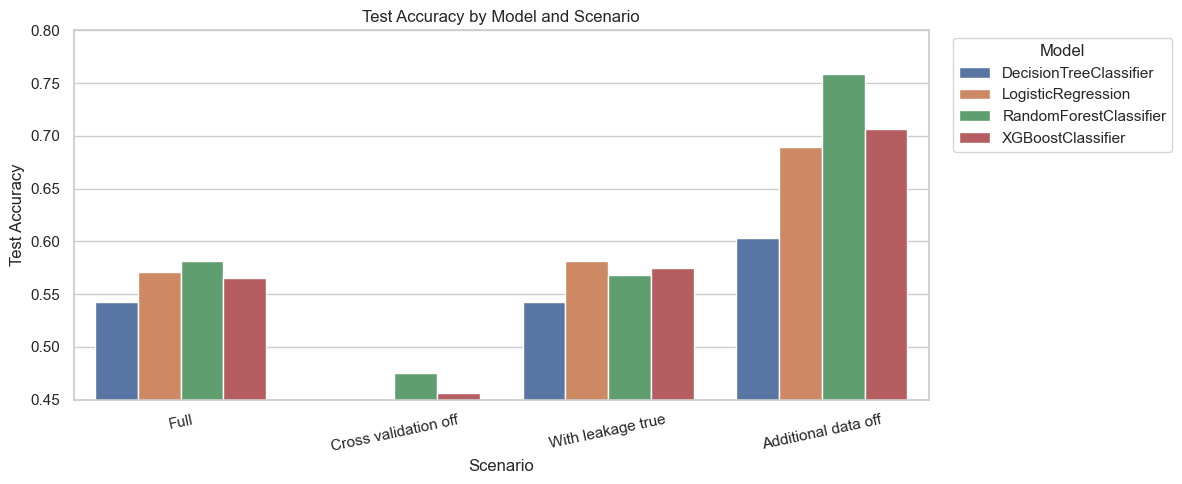

In [22]:
plt.figure(figsize=(12, 5))
sns.barplot(
    data=aligned,
    x="scenario",
    y="test_accuracy",
    hue="model",
)
plt.title("Test Accuracy by Model and Scenario")
plt.ylim(0.45, 0.80)
plt.ylabel("Test Accuracy")
plt.xlabel("Scenario")
plt.xticks(rotation=12)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 5) Validation vs test accuracy

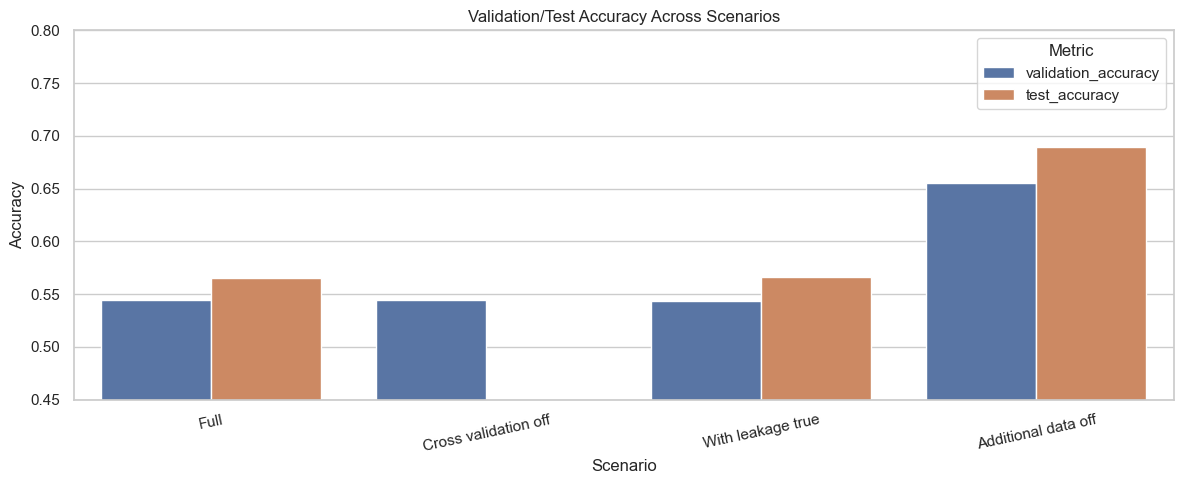

In [23]:
melted = aligned.melt(
    id_vars=["scenario", "model"],
    value_vars=["validation_accuracy", "test_accuracy"],
    var_name="split_metric",
    value_name="accuracy",
)

plt.figure(figsize=(12, 5))
sns.barplot(
    data=melted,
    x="scenario",
    y="accuracy",
    hue="split_metric",
    errorbar=None,
)
plt.title("Validation/Test Accuracy Across Scenarios")
plt.ylim(0.45, 0.80)
plt.ylabel("Accuracy")
plt.xlabel("Scenario")
plt.xticks(rotation=12)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

## 6) Per-model scenario profile

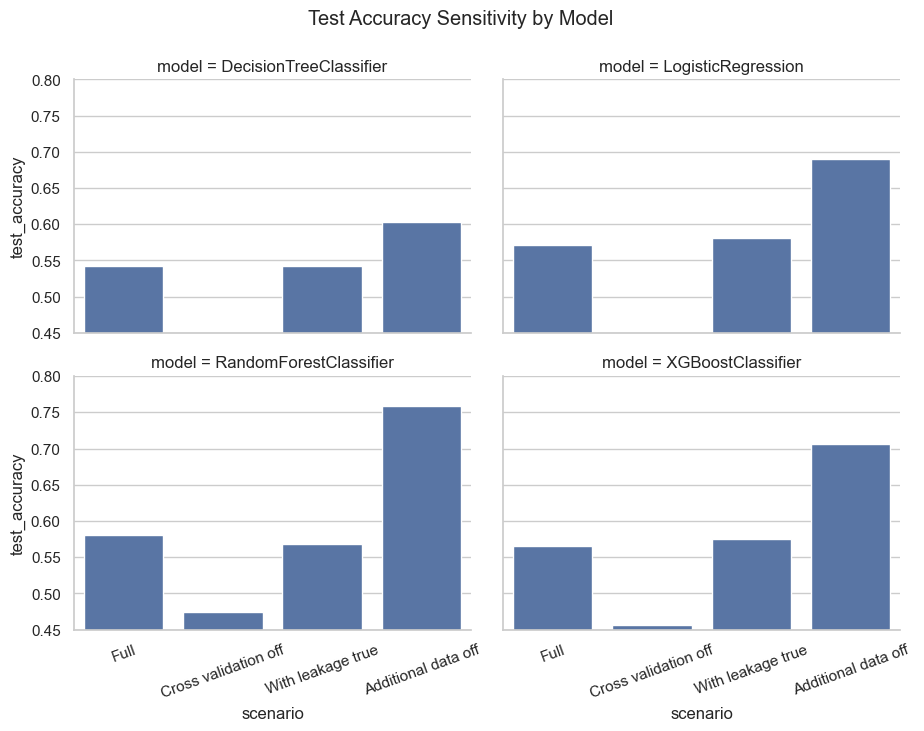

In [24]:
g = sns.catplot(
    data=aligned,
    x="scenario",
    y="test_accuracy",
    col="model",
    kind="bar",
    col_wrap=2,
    sharey=True,
    height=3.5,
    aspect=1.3,
    order=scenario_order,
)
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Test Accuracy Sensitivity by Model")
for ax in g.axes.flat:
    ax.set_ylim(0.45, 0.80)
    ax.tick_params(axis="x", rotation=20)
plt.show()

## 7) Delta vs baseline (`Cross validation off`)

In [25]:
baseline = (
    aligned[aligned["scenario"] == "Cross validation off"][ ["model", "test_accuracy"] ]
    .rename(columns={"test_accuracy": "baseline_test_accuracy"})
)

delta = aligned.merge(baseline, on="model", how="left")
delta["delta_vs_baseline"] = (delta["test_accuracy"] - delta["baseline_test_accuracy"]).round(4)

delta_table = delta[["scenario", "model", "test_accuracy", "baseline_test_accuracy", "delta_vs_baseline"]].sort_values(["model", "scenario"])
delta_table

,scenario,model,test_accuracy,baseline_test_accuracy,delta_vs_baseline
0,Full,DecisionTreeClassifier,0.5422,0.3326,0.2096
4,Cross validation off,DecisionTreeClassifier,0.3326,0.3326,0.0000
8,With leakage true,DecisionTreeClassifier,0.5422,0.3326,0.2096
12,Additional data off,DecisionTreeClassifier,0.6034,0.3326,0.2708
1,Full,LogisticRegression,0.5714,0.4060,0.1654
5,Cross validation off,LogisticRegression,0.4060,0.4060,0.0000
9,With leakage true,LogisticRegression,0.5812,0.4060,0.1752
13,Additional data off,LogisticRegression,0.6897,0.4060,0.2837
2,Full,RandomForestClassifier,0.5812,0.4748,0.1064
6,Cross validation off,RandomForestClassifier,0.4748,0.4748,0.0000


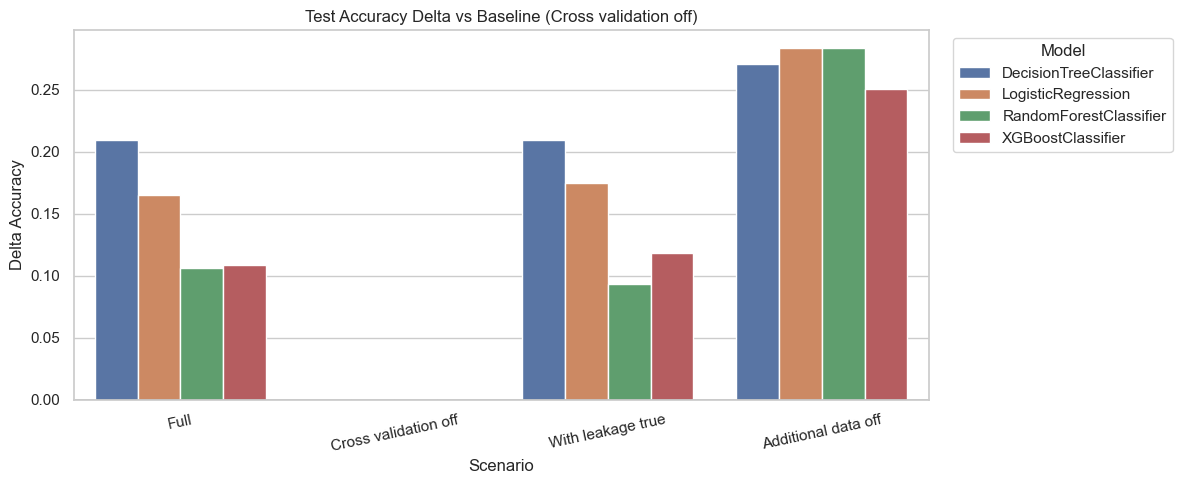

In [26]:
plt.figure(figsize=(12, 5))
sns.barplot(data=delta, x="scenario", y="delta_vs_baseline", hue="model")
plt.axhline(0, color="black", linewidth=1)
plt.title("Test Accuracy Delta vs Baseline (Cross validation off)")
plt.ylabel("Delta Accuracy")
plt.xlabel("Scenario")
plt.xticks(rotation=12)
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 8) Cross-validation metric (where available)

,scenario,model,cv_accuracy
2,Full,RandomForestClassifier,0.5842
3,Full,XGBoostClassifier,0.5755
1,Full,LogisticRegression,0.5694
0,Full,DecisionTreeClassifier,0.4910


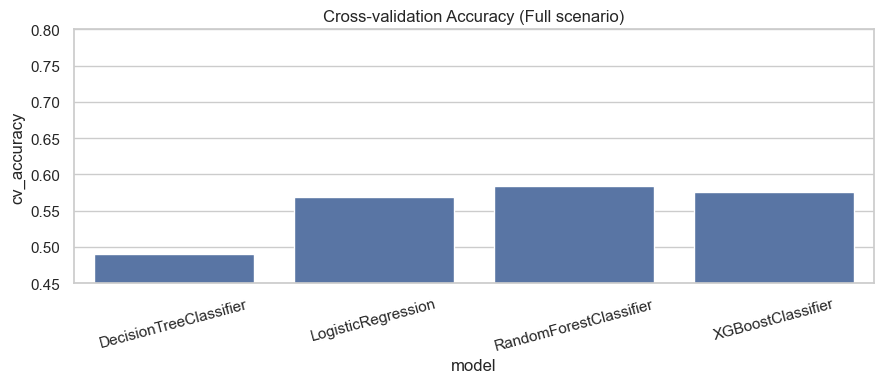

In [27]:
cv_rows = aligned.dropna(subset=["cv_accuracy"]).copy()
if cv_rows.empty:
    print("No CV results found in the current table.")
else:
    display(cv_rows[["scenario", "model", "cv_accuracy"]].sort_values("cv_accuracy", ascending=False))

    plt.figure(figsize=(9, 4))
    sns.barplot(data=cv_rows, x="model", y="cv_accuracy")
    plt.title("Cross-validation Accuracy (Full scenario)")
    plt.ylim(0.45, 0.80)
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()